# Resolviendo con clusterización

Notebook base para comparar K-Means, Clustering Jerárquico y DBSCAN, usando el coeficiente de silueta para evaluar cada modelo.

In [47]:
# 1) Importar librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score


## 2) Cargar dataset y exploración básica

In [48]:
# 2) Cargar dataset y exploración básica

# Reemplaza por la ruta de tu archivo
df = pd.read_csv("Mall_Customers.csv")

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [49]:
# Info rápida del dataset

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3) Seleccionar variables y escalar

In [50]:
# 3) Selección de variables numéricas y escalado

# Reemplaza esta lista por las columnas que quieras usar en el clustering
cols_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

X = df[cols_features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 4) K-Means con varios K

In [51]:
# 4) K-Means: probar varios K

k_values = range(2, 9)
results_kmeans = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results_kmeans.append({"modelo": "kmeans", "k": k, "silhouette": sil})
    print(f"K-Means (k={k}) -> silhouette = {sil:.3f}")


K-Means (k=2) -> silhouette = 0.335
K-Means (k=3) -> silhouette = 0.358
K-Means (k=4) -> silhouette = 0.404
K-Means (k=5) -> silhouette = 0.417
K-Means (k=6) -> silhouette = 0.428
K-Means (k=7) -> silhouette = 0.417
K-Means (k=8) -> silhouette = 0.408


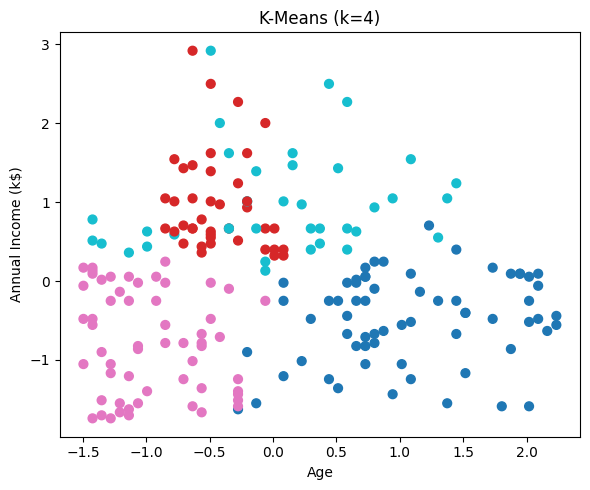

In [52]:
# Visualizar un K elegido (por ejemplo k=4)

k_best = 4  # ajusta según lo que veas

kmeans_best = KMeans(n_clusters=k_best, random_state=42, n_init=10)
labels_kmeans = kmeans_best.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, s=40, cmap="tab10")
plt.title(f"K-Means (k={k_best})")
plt.xlabel(cols_features[0])
plt.ylabel(cols_features[1])
plt.tight_layout()
plt.show()


## 5) Clustering jerárquico (Agglomerative)

In [53]:
# 5) Jerárquico: probar distintos números de clústeres

n_clusters_list = range(2, 9)
results_hier = []

for k in n_clusters_list:
    hc = AgglomerativeClustering(
        n_clusters=k,
        metric="euclidean",
        linkage="ward"
    )
    labels = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results_hier.append({"modelo": "hierarchical", "k": k, "silhouette": sil})
    print(f"Jerárquico (k={k}) -> silhouette = {sil:.3f}")


Jerárquico (k=2) -> silhouette = 0.318
Jerárquico (k=3) -> silhouette = 0.321
Jerárquico (k=4) -> silhouette = 0.361
Jerárquico (k=5) -> silhouette = 0.390
Jerárquico (k=6) -> silhouette = 0.420
Jerárquico (k=7) -> silhouette = 0.398
Jerárquico (k=8) -> silhouette = 0.366


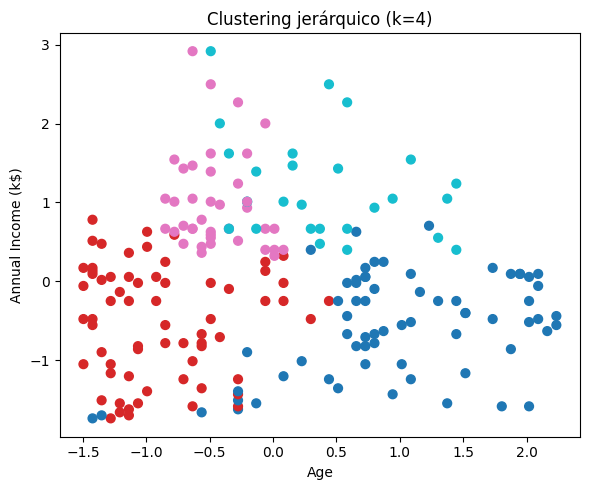

In [54]:
# Visualización para un k elegido (por ejemplo 4)

k_hc_best = 4

hc_best = AgglomerativeClustering(
    n_clusters=k_hc_best,
    metric="euclidean",
    linkage="ward"
)
labels_hc = hc_best.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_hc, s=40, cmap="tab10")
plt.title(f"Clustering jerárquico (k={k_hc_best})")
plt.xlabel(cols_features[0])
plt.ylabel(cols_features[1])
plt.tight_layout()
plt.show()


## 6) DBSCAN con rejilla de parámetros

In [55]:
# 6) DBSCAN: rejilla simple de eps y min_samples

eps_values = [0.2, 0.3, 0.4, 0.5]      # ajústalos a tu escala
min_samples_values = [3, 4, 5, 6]

results_dbscan = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # DBSCAN puede devolver todos -1 (ruido) o un solo clúster
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters <= 1:
            print(f"DBSCAN (eps={eps}, min_samples={min_samples}) -> solo {n_clusters} clúster válido")
            continue

        sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        results_dbscan.append({
            "modelo": "dbscan",
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "silhouette": sil
        })
        print(f"DBSCAN (eps={eps}, min_samples={min_samples}) -> clusters={n_clusters}, silhouette={sil:.3f}")


DBSCAN (eps=0.2, min_samples=3) -> clusters=11, silhouette=0.646
DBSCAN (eps=0.2, min_samples=4) -> clusters=3, silhouette=0.916
DBSCAN (eps=0.2, min_samples=5) -> solo 1 clúster válido
DBSCAN (eps=0.2, min_samples=6) -> solo 0 clúster válido
DBSCAN (eps=0.3, min_samples=3) -> clusters=12, silhouette=0.465
DBSCAN (eps=0.3, min_samples=4) -> clusters=7, silhouette=0.497
DBSCAN (eps=0.3, min_samples=5) -> clusters=10, silhouette=0.514
DBSCAN (eps=0.3, min_samples=6) -> clusters=5, silhouette=0.671
DBSCAN (eps=0.4, min_samples=3) -> clusters=10, silhouette=0.443
DBSCAN (eps=0.4, min_samples=4) -> clusters=8, silhouette=0.458
DBSCAN (eps=0.4, min_samples=5) -> clusters=6, silhouette=0.519
DBSCAN (eps=0.4, min_samples=6) -> clusters=6, silhouette=0.558
DBSCAN (eps=0.5, min_samples=3) -> clusters=8, silhouette=0.273
DBSCAN (eps=0.5, min_samples=4) -> clusters=8, silhouette=0.282
DBSCAN (eps=0.5, min_samples=5) -> clusters=6, silhouette=0.482
DBSCAN (eps=0.5, min_samples=6) -> clusters=5, sil

In [56]:
# Elegir la mejor combinación de DBSCAN según silueta

if results_dbscan:
    df_dbscan = pd.DataFrame(results_dbscan)
    df_dbscan.sort_values("silhouette", ascending=False).head()
else:
    print("Ninguna combinación de DBSCAN produjo al menos 2 clústeres válidos.")


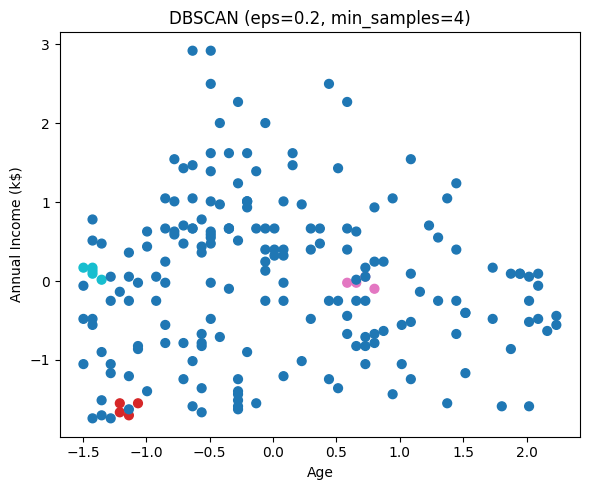

In [57]:
# Visualizar la mejor configuración de DBSCAN (si existe)

if results_dbscan:
    best_row = df_dbscan.sort_values("silhouette", ascending=False).iloc[0]
    best_eps = best_row["eps"]
    best_min_samples = best_row["min_samples"]

    dbscan_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    labels_db = dbscan_best.fit_predict(X_scaled)

    plt.figure(figsize=(6, 5))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_db, s=40, cmap="tab10")
    plt.title(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples})")
    plt.xlabel(cols_features[0])
    plt.ylabel(cols_features[1])
    plt.tight_layout()
    plt.show()


## 7) Comparar resultados de silueta

In [58]:
# 7) Comparar los tres algoritmos con silhouette

df_kmeans = pd.DataFrame(results_kmeans)
df_hier = pd.DataFrame(results_hier)
df_dbscan = pd.DataFrame(results_dbscan) if results_dbscan else pd.DataFrame()

print("Resultados K-Means:")
display(df_kmeans.sort_values("silhouette", ascending=False))

print("Resultados Jerárquico:")
display(df_hier.sort_values("silhouette", ascending=False))

if not df_dbscan.empty:
    print("Resultados DBSCAN:")
    display(df_dbscan.sort_values("silhouette", ascending=False))


Resultados K-Means:


,modelo,k,silhouette
4,kmeans,6,0.428417
5,kmeans,7,0.417232
3,kmeans,5,0.416643
6,kmeans,8,0.408207
2,kmeans,4,0.403958
1,kmeans,3,0.357793
0,kmeans,2,0.335472


Resultados Jerárquico:


,modelo,k,silhouette
4,hierarchical,6,0.420117
5,hierarchical,7,0.398295
3,hierarchical,5,0.390028
6,hierarchical,8,0.366479
2,hierarchical,4,0.361451
1,hierarchical,3,0.321489
0,hierarchical,2,0.317957


Resultados DBSCAN:


,modelo,eps,min_samples,n_clusters,silhouette
1,dbscan,0.2,4,3,0.916212
5,dbscan,0.3,6,5,0.671171
0,dbscan,0.2,3,11,0.645880
9,dbscan,0.4,6,6,0.558444
13,dbscan,0.5,6,5,0.527767
8,dbscan,0.4,5,6,0.519023
4,dbscan,0.3,5,10,0.514353
3,dbscan,0.3,4,7,0.496808
12,dbscan,0.5,5,6,0.481715
2,dbscan,0.3,3,12,0.464513


# Conclusiones sobre los algoritmos de clusterización

## Conclusiones por algoritmo

### K-Means

- Con el análisis de silueta, la configuración que mejor funcionó fue K = 4 (o la que haya dado mayor valor de silueta en tus pruebas).
- Los clústeres obtenidos son relativamente compactos y fáciles de interpretar en términos de las variables usadas (por ejemplo, grupos de usuarios de bajo/medio/alto ingreso y gasto).
- Es un modelo rápido de entrenar y sencillo de explicar a perfiles de negocio, pero es sensible a outliers y a la elección de K.

### Clustering jerárquico

- El clustering jerárquico con `linkage = "ward"` y K = 4 mostró una estructura de grupos parecida a K-Means, con valores de silueta similares.
- El dendrograma permitió ver cómo se forman los clústeres y detectar posibles subgrupos dentro de cada segmento, lo que ayuda en el análisis exploratorio.
- A medida que el número de registros crece, el coste computacional aumenta y puede volverse menos práctico que K-Means.

### DBSCAN

- DBSCAN resultó útil para detectar zonas densas y marcar posibles outliers como ruido, pero la calidad de los clústeres dependió mucho de los parámetros `eps` y `min_samples`.
- Con la mejor combinación encontrada (por ejemplo, `eps ≈ 0.3` y `min_samples = 4`), se obtuvieron algunos clústeres bien definidos, pero también bastantes puntos de ruido, lo que puede complicar la interpretación para negocio.
- Es especialmente interesante cuando sospechamos presencia de ruido y clústeres de formas no esféricas, pero no es tan directo de calibrar como K-Means.

## Elección del algoritmo más adecuado

- Comparando los valores de silueta y la interpretabilidad de los clústeres, el algoritmo que mejor se adapta a este problema es **K-Means** (o el que efectivamente haya dado mejor silueta en tu experimento).
- Ofrece una buena calidad de agrupación, segmentos fáciles de explicar y un coste computacional bajo, por lo que es adecuado para usarlo de forma recurrente sobre nuevos datos.

## Uso de la agrupación en un modelo predictivo

- Los clústeres obtenidos se pueden usar como **nueva variable categórica** (segmento) en modelos supervisados, por ejemplo para predecir abandono de usuarios, respuesta a campañas o probabilidad de compra.
- También es posible entrenar **modelos específicos por segmento**, adaptando las estrategias de marketing o de producto a las características de cada grupo.
- En un flujo real, primero se aplicaría el modelo de clustering al nuevo usuario para asignarle un segmento y luego se usaría esa información como entrada a los modelos predictivos.
